<a href="https://colab.research.google.com/github/siamabdurrahman/Brain-Tumour-Classification/blob/Brain-Tumour-Detection-from-MRI-Images-Using-Convolutional-Neural-Networks-and-Transfer-Learning/Brain_Tumour_Detection_from_MRI_Images_Using_Convolutional_Neural_Networks_and_Transfer_Learning_(Final_Version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumour Detection from MRI Images Using Convolutional Neural Networks and Transfer Learning (Assessment 2 - Final Version)



This notebook formalizes the initial development phase of the Brain Tumour Classification project into a structured, auditable, and reproducible Google Colab workflow. Utilizing the provided Kaggle archive.zip image dataset, the research frames the objective as a binary image-classification problem: the primary task is to develop a predictive model capable of distinguishing between brain MRI scans belonging to the yes (pathological) and no (healthy) classes.


> Kaggle page URL : https://www.kaggle.com/datasets/mohamada2274/brain-tumor-mri-yes-or-no


In [1]:
# ==============================================================
# A. GOOGLE COLAB ENVIRONMENT CHECK
# ==============================================================
# Purpose:
# - Confirm whether the notebook is running inside Google Colab.
# - Confirm GPU availability for transfer learning.
# - Keep setup code explicit so that the work is easy to audit.

import os
import sys
import json
import time
import math
import shutil
import random
import zipfile
import hashlib
import warnings
from pathlib import Path

# Colab-specific imports are optional. The notebook remains readable outside Colab.
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    files = None
    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")
print(f"Python version: {sys.version.split()[0]}")

# TensorFlow is pre-installed in standard Colab GPU runtimes.
# If this import fails in Colab, install/enable a TensorFlow runtime before continuing.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile, UnidentifiedImageError

import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    brier_score_loss,
)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# GPU diagnostics. Training is possible on CPU, but GPU is recommended for MobileNetV2.
gpus = tf.config.list_physical_devices("GPU")
print("Detected GPU devices:", gpus)
if not gpus:
    warnings.warn(
        "No GPU was detected. For final training, use Runtime -> Change runtime type -> GPU in Colab.",
        RuntimeWarning,
    )

# Let PIL load truncated images where possible, while still recording image quality issues.
ImageFile.LOAD_TRUNCATED_IMAGES = True


Running in Google Colab: True
Python version: 3.12.13
TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Detected GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ==============================================================
# B. GLOBAL CONFIGURATION AND REPRODUCIBILITY
# ==============================================================
# Purpose:
# - Define all experimental constants in one cell.
# - Fix random seeds for reproducible data splitting and model initialisation.
# - Create a clean project folder structure for report-ready outputs.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# The exact Kaggle URL is required in the written report. Paste it here before submission.
KAGGLE_DATASET_URL = "PASTE_THE_EXACT_KAGGLE_DATASET_URL_HERE"

# Colab uses /content as the working directory. Outside Colab, use the current folder.
BASE_DIR = Path("/content") if IN_COLAB else Path.cwd()
PROJECT_DIR = BASE_DIR / "brain_tumour_mobilenetv2_high_distinction"
DATA_DIR = PROJECT_DIR / "data"
EXTRACT_DIR = DATA_DIR / "extracted"
FIGURE_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
MODEL_DIR = PROJECT_DIR / "models"
NOTES_DIR = PROJECT_DIR / "report_notes"

for directory in [DATA_DIR, EXTRACT_DIR, FIGURE_DIR, RESULTS_DIR, MODEL_DIR, NOTES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Model and data constants.
CLASS_NAMES = ["no", "yes"]                 # Alphabetical, explicit and auditable.
LABEL_TO_ID = {"no": 0, "yes": 1}
ID_TO_LABEL = {0: "no", 1: "yes"}
POSITIVE_CLASS_NAME = "yes"

IMG_SIZE = (224, 224)                         # Required by standard MobileNetV2 input usage.
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Training schedule. Early stopping usually stops before the maximum epoch count.
BASELINE_EPOCHS = 12
MOBILENET_HEAD_EPOCHS = 15
MOBILENET_FINE_TUNE_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 5

# Fine-tuning: unfreeze only the top quarter of the MobileNetV2 feature extractor.
FINE_TUNE_FRACTION = 0.25

# Bootstrap repetitions for confidence intervals. Increase to 2000+ for a slower final statistical analysis.
BOOTSTRAP_REPEATS = 1000

# Save a copy of the configuration for reproducibility.
config = {
    "seed": SEED,
    "kaggle_dataset_url": KAGGLE_DATASET_URL,
    "class_names": CLASS_NAMES,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "baseline_epochs": BASELINE_EPOCHS,
    "mobilenet_head_epochs": MOBILENET_HEAD_EPOCHS,
    "mobilenet_fine_tune_epochs": MOBILENET_FINE_TUNE_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "fine_tune_fraction": FINE_TUNE_FRACTION,
    "bootstrap_repeats": BOOTSTRAP_REPEATS,
}

with open(PROJECT_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print("Project directory:", PROJECT_DIR)
print(json.dumps(config, indent=4))


Project directory: /content/brain_tumour_mobilenetv2_high_distinction
{
    "seed": 42,
    "kaggle_dataset_url": "PASTE_THE_EXACT_KAGGLE_DATASET_URL_HERE",
    "class_names": [
        "no",
        "yes"
    ],
    "image_size": [
        224,
        224
    ],
    "batch_size": 32,
    "baseline_epochs": 12,
    "mobilenet_head_epochs": 15,
    "mobilenet_fine_tune_epochs": 15,
    "early_stopping_patience": 5,
    "fine_tune_fraction": 0.25,
    "bootstrap_repeats": 1000
}


## 1. Dataset extraction from the supplied Kaggle ZIP

The assessment requires a real Kaggle dataset and a structured machine-learning pipeline. This section uses only the supplied `archive.zip`. It expects the following folder structure after extraction:

```text
Brain (y-n)/Training/no
Brain (y-n)/Training/yes
```

The code below is Colab-ready: if `/content/archive.zip` is missing, it prompts you to upload the file.


In [3]:
# ==============================================================
# 1A. LOCATE, UPLOAD AND EXTRACT THE KAGGLE ZIP DATASET
# ==============================================================
# Purpose:
# - Use the supplied archive.zip only.
# - Avoid hard-coded Google Drive paths.
# - Validate the expected Kaggle folder structure before modelling.

def locate_or_upload_zip() -> Path:
    """Return the archive.zip path, prompting for upload in Colab when needed."""
    candidate_paths = [
        BASE_DIR / "archive.zip",          # Standard Colab upload location.
        Path.cwd() / "archive.zip",        # Local notebook folder.
        Path("/mnt/data/archive.zip"),     # Editing sandbox path; harmless in Colab.
    ]

    for candidate in candidate_paths:
        if candidate.exists():
            print(f"Found dataset ZIP at: {candidate}")
            return candidate

    if IN_COLAB and files is not None:
        print("archive.zip was not found. Please upload the supplied Kaggle archive.zip now.")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file was uploaded. Please upload archive.zip and rerun this cell.")
        uploaded_name = next(iter(uploaded.keys()))
        uploaded_path = BASE_DIR / uploaded_name
        if uploaded_path.name != "archive.zip":
            renamed_path = BASE_DIR / "archive.zip"
            shutil.move(str(uploaded_path), str(renamed_path))
            uploaded_path = renamed_path
        print(f"Uploaded dataset ZIP to: {uploaded_path}")
        return uploaded_path

    raise FileNotFoundError(
        "Could not locate archive.zip. Place it beside this notebook or upload it in Colab."
    )

zip_path = locate_or_upload_zip()

# Extract only once. If already extracted, reuse the extracted folder to save time.
expected_root = EXTRACT_DIR / "Brain (y-n)" / "Training"
if not expected_root.exists():
    print("Extracting dataset. This may take a moment...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print("Dataset already extracted. Reusing existing files.")

# Validate expected class folders.
for class_name in CLASS_NAMES:
    class_dir = expected_root / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Expected class folder missing: {class_dir}")

print("Dataset root:", expected_root)
print("Class folders:", [str(expected_root / c) for c in CLASS_NAMES])


Found dataset ZIP at: /content/archive.zip
Extracting dataset. This may take a moment...
Dataset root: /content/brain_tumour_mobilenetv2_high_distinction/data/extracted/Brain (y-n)/Training
Class folders: ['/content/brain_tumour_mobilenetv2_high_distinction/data/extracted/Brain (y-n)/Training/no', '/content/brain_tumour_mobilenetv2_high_distinction/data/extracted/Brain (y-n)/Training/yes']


## 2. Dataset audit: samples, labels, class distribution, duplicates and image quality

A high-distinction methodology should not move directly from files to modelling. It should first audit the dataset for:

- the number of samples;
- the target variable and class distribution;
- corrupt or unreadable images;
- image dimensions and colour modes;
- exact duplicates that could cause data leakage if the same image appears in both training and testing.


In [4]:
# ==============================================================
# 2A. BUILD AN AUDITABLE IMAGE DATAFRAME
# ==============================================================
# Purpose:
# - Convert folder structure into a tabular dataset manifest.
# - Validate every image with PIL.
# - Hash file bytes to identify exact duplicates.
# - Save all intermediate metadata for transparent reporting.

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def sha1_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    """Compute a stable SHA-1 hash for exact duplicate detection."""
    digest = hashlib.sha1()
    with path.open("rb") as file_obj:
        for chunk in iter(lambda: file_obj.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def inspect_image(path: Path) -> dict:
    """Read image metadata and return a dictionary describing image quality."""
    record = {
        "filepath": str(path),
        "filename": path.name,
        "extension": path.suffix.lower(),
        "is_readable": False,
        "width": np.nan,
        "height": np.nan,
        "mode": None,
        "sha1": None,
        "error": None,
    }
    try:
        with Image.open(path) as img:
            img.verify()  # Verify file integrity without decoding full pixel data.
        with Image.open(path) as img:
            record["width"], record["height"] = img.size
            record["mode"] = img.mode
        record["sha1"] = sha1_file(path)
        record["is_readable"] = True
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        record["error"] = repr(exc)
    return record

records = []

for class_name in CLASS_NAMES:
    class_dir = expected_root / class_name
    image_paths = sorted([
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ])

    for image_path in image_paths:
        image_record = inspect_image(image_path)
        image_record["label"] = class_name
        image_record["label_id"] = LABEL_TO_ID[class_name]
        records.append(image_record)

raw_df = pd.DataFrame(records)
raw_df.to_csv(RESULTS_DIR / "dataset_audit_raw.csv", index=False)

# Keep readable images and remove exact duplicates before splitting.
readable_df = raw_df[raw_df["is_readable"]].copy()
duplicate_mask = readable_df.duplicated(subset="sha1", keep="first")
duplicate_df = readable_df[duplicate_mask].copy()
clean_df = readable_df[~duplicate_mask].copy().reset_index(drop=True)

# Persist tables for the portfolio appendix.
duplicate_df.to_csv(RESULTS_DIR / "exact_duplicate_images_removed.csv", index=False)
clean_df.to_csv(RESULTS_DIR / "dataset_clean_manifest.csv", index=False)

print(f"Total image files found: {len(raw_df):,}")
print(f"Readable images: {len(readable_df):,}")
print(f"Unreadable/corrupt images: {(~raw_df['is_readable']).sum():,}")
print(f"Exact duplicate images removed: {len(duplicate_df):,}")
print(f"Clean modelling images: {len(clean_df):,}")

display(clean_df.head())


Total image files found: 5,450
Readable images: 5,450
Unreadable/corrupt images: 0
Exact duplicate images removed: 394
Clean modelling images: 5,056


,filepath,filename,extension,is_readable,width,height,mode,sha1,error,label,label_id
0,/content/brain_tumour_mobilenetv2_high_distinc...,02ac46b7eab4a327a468b0f26d17c9_big_gallery.jpeg,.jpeg,True,630,630,RGB,7ab7bc4aaab916a2fcffba2a3dccaef1e6888231,None,no,0
1,/content/brain_tumour_mobilenetv2_high_distinc...,02e7d2ead4cde2cb075b86925f2813_big_gallery.jpeg,.jpeg,True,630,630,RGB,32c6a1602bb701216d32e5ec5a2bae7d015ca7fa,None,no,0
2,/content/brain_tumour_mobilenetv2_high_distinc...,03a9560561f3e35f24f6ce62150e9e_big_gallery.jpeg,.jpeg,True,630,630,L,13b0c2a131968b09929dcf669d07734d97e76c5b,None,no,0
3,/content/brain_tumour_mobilenetv2_high_distinc...,03b8cddedf7fef67b544b2b2e546c9_big_gallery.jpeg,.jpeg,True,630,630,L,1cdf1cfa049be010b67bfd31d9db954ac431248e,None,no,0
4,/content/brain_tumour_mobilenetv2_high_distinc...,04024298ac9373718c8a182dad6eb4_big_gallery.jpeg,.jpeg,True,630,630,L,c0cec3b30f5c1462c09ef3427aafc36d5d369257,None,no,0


Class distribution:


,class_label,image_count,percentage
0,no,2473,48.91
1,yes,2583,51.09


Image dimension summary:


,width,height
count,5056.00,5056.00
mean,327.79,339.77
std,158.83,169.08
min,150.00,168.00
25%,224.00,224.00
50%,224.00,224.00
75%,456.00,512.00
max,1149.00,1019.00


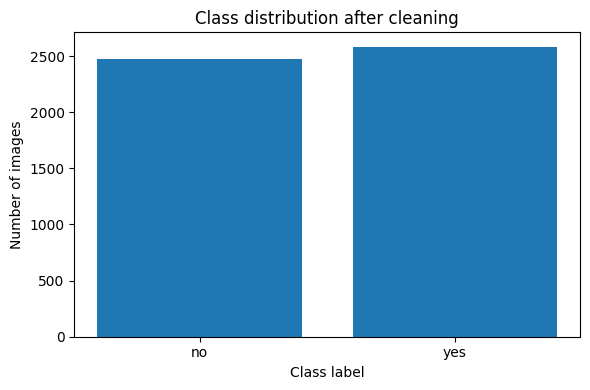

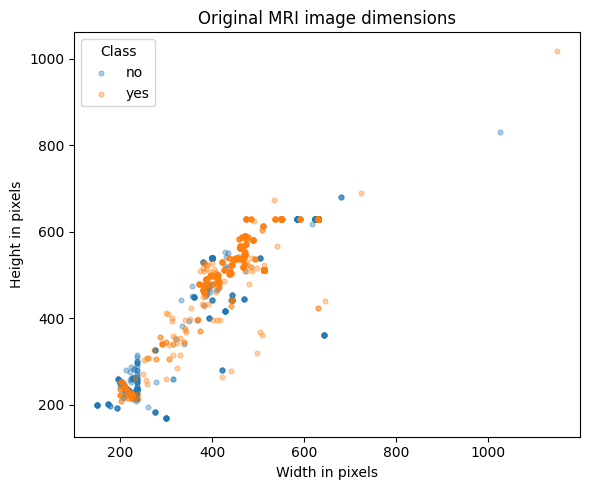

In [5]:
# ==============================================================
# 2B. CLASS DISTRIBUTION AND IMAGE-DIMENSION SUMMARY
# ==============================================================
# Purpose:
# - Create the dataset-description outputs required by the assessment.
# - Save tables and figures that can be inserted into the written report.

class_distribution = (
    clean_df["label"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("class_label")
    .reset_index(name="image_count")
)
class_distribution["percentage"] = (
    100 * class_distribution["image_count"] / class_distribution["image_count"].sum()
).round(2)
class_distribution.to_csv(RESULTS_DIR / "class_distribution.csv", index=False)

image_dimension_summary = clean_df[["width", "height"]].describe().round(2)
image_dimension_summary.to_csv(RESULTS_DIR / "image_dimension_summary.csv")

print("Class distribution:")
display(class_distribution)
print("Image dimension summary:")
display(image_dimension_summary)

# Class distribution figure.
plt.figure(figsize=(6, 4))
plt.bar(class_distribution["class_label"], class_distribution["image_count"])
plt.title("Class distribution after cleaning")
plt.xlabel("Class label")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=300)
plt.show()

# Image dimension scatter plot.
plt.figure(figsize=(6, 5))
for class_name in CLASS_NAMES:
    subset = clean_df[clean_df["label"] == class_name]
    plt.scatter(subset["width"], subset["height"], alpha=0.35, label=class_name, s=12)
plt.title("Original MRI image dimensions")
plt.xlabel("Width in pixels")
plt.ylabel("Height in pixels")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "image_dimension_scatter.png", dpi=300)
plt.show()


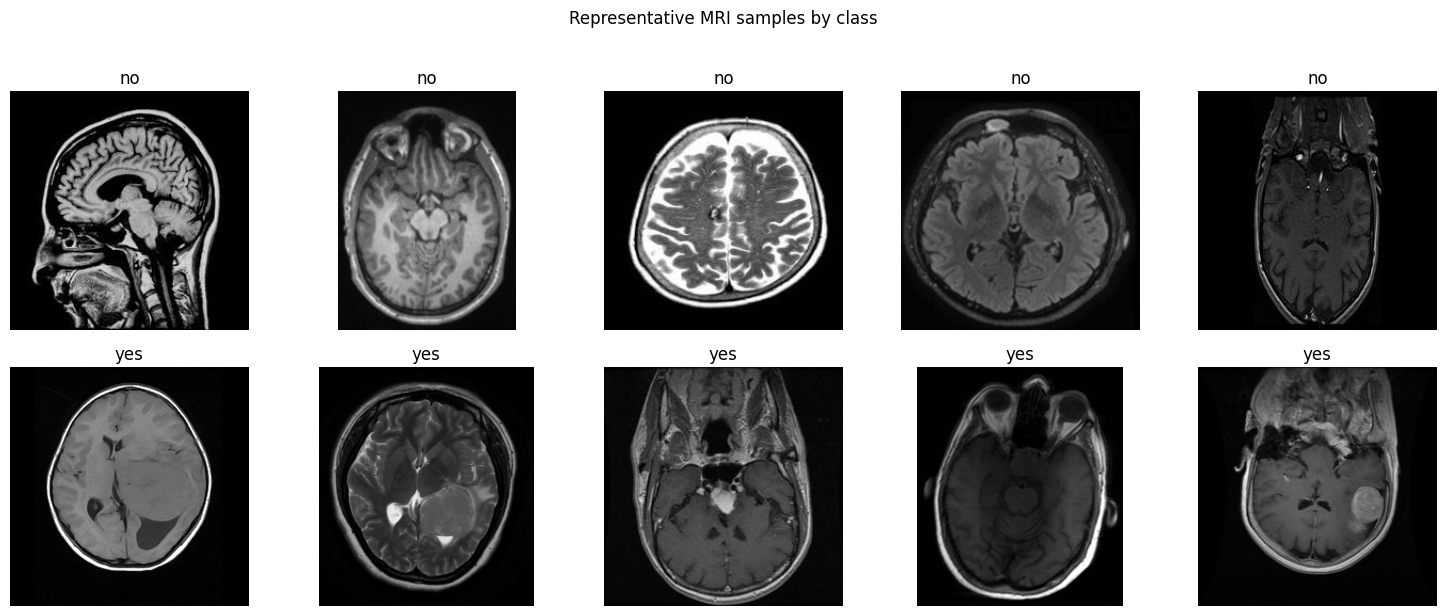

In [6]:
# ==============================================================
# 2C. VISUAL INSPECTION OF REPRESENTATIVE IMAGES
# ==============================================================
# Purpose:
# - Provide visual evidence that the dataset is image-based MRI data.
# - Support the report's dataset description and qualitative audit.

sample_per_class = 5
fig, axes = plt.subplots(len(CLASS_NAMES), sample_per_class, figsize=(15, 6))

for row_index, class_name in enumerate(CLASS_NAMES):
    class_paths = clean_df.loc[clean_df["label"] == class_name, "filepath"].tolist()
    selected_paths = random.sample(class_paths, min(sample_per_class, len(class_paths)))

    for col_index, image_path in enumerate(selected_paths):
        image = Image.open(image_path).convert("RGB")
        axes[row_index, col_index].imshow(image)
        axes[row_index, col_index].axis("off")
        axes[row_index, col_index].set_title(class_name)

plt.suptitle("Representative MRI samples by class", y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "representative_mri_samples.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Stratified train/validation/test split

The split is performed after duplicate removal to reduce data-leakage risk. The test set remains untouched until final evaluation. The validation set is used for model selection, early stopping and threshold tuning.


In [7]:
# ==============================================================
# 3. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ==============================================================
# Purpose:
# - Satisfy the assessment requirement for train/validation/test splitting.
# - Preserve class proportions with stratification.
# - Keep the test set independent for final performance reporting.

train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=SEED,
    stratify=clean_df["label_id"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"],
)

# Reset indices so that saved CSV files are clean and readable.
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Save split manifests for reproducibility.
train_df.to_csv(RESULTS_DIR / "train_split_manifest.csv", index=False)
val_df.to_csv(RESULTS_DIR / "validation_split_manifest.csv", index=False)
test_df.to_csv(RESULTS_DIR / "test_split_manifest.csv", index=False)

# Leakage checks: file paths should not overlap between partitions.
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)

split_summary = pd.concat(
    [
        train_df["label"].value_counts().rename("train"),
        val_df["label"].value_counts().rename("validation"),
        test_df["label"].value_counts().rename("test"),
    ],
    axis=1,
).reindex(CLASS_NAMES)
split_summary.loc["TOTAL"] = split_summary.sum(axis=0)
split_summary.to_csv(RESULTS_DIR / "split_summary.csv")

print("Split summary:")
display(split_summary)


Split summary:


,train,validation,test
label,,,
no,1731,371,371
yes,1808,387,388
TOTAL,3539,758,759


## 4. Preprocessing pipeline: resizing, normalisation, augmentation and class weights

For MobileNetV2, every image is resized to **224 x 224**. Pixel scaling is performed inside the model using a serialisable Keras `Rescaling` layer equivalent to MobileNetV2 `preprocess_input`, mapping 0-255 pixels to the range expected by ImageNet-pretrained MobileNetV2. Augmentation is applied only during training, not validation or testing.


In [8]:
# ==============================================================
# 4A. TF.DATA INPUT PIPELINE
# ==============================================================
# Purpose:
# - Efficiently load images from file paths.
# - Resize images consistently.
# - Keep augmentation inside the model, where it is active only during training.


def dataframe_to_dataset(dataframe: pd.DataFrame, shuffle: bool) -> tf.data.Dataset:
    """Convert a dataframe of file paths and labels into a batched tf.data.Dataset."""
    filepaths = dataframe["filepath"].astype(str).values
    labels = dataframe["label_id"].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def load_image(filepath: tf.Tensor, label: tf.Tensor):
        # Read raw image bytes from disk.
        image_bytes = tf.io.read_file(filepath)

        # decode_image supports common formats and keeps the pipeline flexible.
        image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])

        # Resize to MobileNetV2 input dimensions.
        image = tf.image.resize(image, IMG_SIZE, method="bilinear")
        image = tf.cast(image, tf.float32)
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = dataframe_to_dataset(train_df, shuffle=True)
val_ds = dataframe_to_dataset(val_df, shuffle=False)
test_ds = dataframe_to_dataset(test_df, shuffle=False)

# Inspect one batch to confirm tensor shapes.
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


In [9]:
# ==============================================================
# 4B. TRAINING-TIME AUGMENTATION AND CLASS-WEIGHT HANDLING
# ==============================================================
# Purpose:
# - Data augmentation improves generalisation and reduces overfitting.
# - Class weights are computed automatically; balanced data should produce weights close to 1.

# Keras preprocessing layers apply transformations only when the model is called with training=True.
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomContrast(0.10, seed=SEED),
    ],
    name="training_only_data_augmentation",
)

# Compute class weights using the training split only to avoid test-set leakage.
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label_id"].values,
)
class_weights = {int(class_id): float(weight) for class_id, weight in zip([0, 1], class_weight_values)}

class_weight_table = pd.DataFrame(
    {
        "class_id": [0, 1],
        "class_label": [ID_TO_LABEL[0], ID_TO_LABEL[1]],
        "class_weight": [class_weights[0], class_weights[1]],
    }
)
class_weight_table.to_csv(RESULTS_DIR / "class_weights.csv", index=False)

print("Class weights computed from the training split:")
display(class_weight_table)


Class weights computed from the training split:


,class_id,class_label,class_weight
0,0,no,1.022241
1,1,yes,0.978706


## 5. Model design and implementation

Two models are used to strengthen the methodology:

1. **Baseline CNN from scratch**: a transparent benchmark that shows what can be learned without transfer learning.
2. **MobileNetV2 transfer-learning model**: a lightweight pretrained convolutional architecture, adapted to the binary MRI task using a new classifier head and later fine-tuned on the upper feature-extractor layers.

The comparison helps justify model selection rather than simply presenting one model in isolation.


In [10]:
# ==============================================================
# 5A. BASELINE CNN FROM SCRATCH
# ==============================================================
# Purpose:
# - Provide a fair benchmark for the transfer-learning model.
# - Use the same data split and augmentation strategy.


def build_baseline_cnn() -> tf.keras.Model:
    """Build a compact CNN baseline for binary image classification."""
    inputs = layers.Input(shape=IMG_SIZE + (3,), name="input_image")

    # Augmentation is active only during training.
    x = data_augmentation(inputs)

    # Baseline CNN expects pixel values scaled to 0-1.
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)

    # Convolutional feature extraction blocks.
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv_block1_conv")(x)
    x = layers.MaxPooling2D(name="conv_block1_pool")(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv_block2_conv")(x)
    x = layers.MaxPooling2D(name="conv_block2_pool")(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv_block3_conv")(x)
    x = layers.MaxPooling2D(name="conv_block3_pool")(x)

    # Global average pooling reduces parameter count compared with Flatten.
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.35, seed=SEED, name="dropout_regularisation")(x)
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="dense_features")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="tumour_probability")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="baseline_cnn")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_only_data_augmentation │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_0_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1_conv (Conv2D)       │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block1_pool (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2_conv (Conv2D)       │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2_pool (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block3_conv (Conv2D)       │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block3_pool (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularisation          │ (None, 128)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_features (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tumour_probability (Dense)      │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================
# 5B. TRAIN THE BASELINE CNN
# ==============================================================
# Purpose:
# - Train the benchmark model using early stopping.
# - Save the best validation-AUC checkpoint for transparent comparison.

baseline_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "best_baseline_cnn.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(RESULTS_DIR / "baseline_training_log.csv")),
]

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    class_weight=class_weights,
    callbacks=baseline_callbacks,
    verbose=1,
)


Epoch 1/12
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5248 - auc: 0.5537 - loss: 0.6963 - precision: 0.5502 - recall: 0.2718
Epoch 1: val_auc improved from None to 0.65602, saving model to /content/brain_tumour_mobilenetv2_high_distinction/models/best_baseline_cnn.keras

Epoch 1: finished saving model to /content/brain_tumour_mobilenetv2_high_distinction/models/best_baseline_cnn.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - accuracy: 0.5369 - auc: 0.5634 - loss: 0.6942 - precision: 0.5604 - recall: 0.4336 - val_accuracy: 0.5475 - val_auc: 0.6560 - val_loss: 0.6928 - val_precision: 0.6692 - val_recall: 0.2248
Epoch 2/12
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5929 - auc: 0.6246 - loss: 0.6784 - precision: 0.5970 - recall: 0.5337
Epoch 2: val_auc improved from 0.65602 to 0.71054, saving model to /content/brain_tumour_mobilenetv2_high_distinction/models/best_baseline_cnn.keras

Epoch 2: finished saving model to /content/brain_tumour_mobilenetv2_high_disti

In [ ]:
# ==============================================================
# 5C. MOBILENETV2 TRANSFER-LEARNING MODEL
# ==============================================================
# Purpose:
# - Reuse ImageNet-pretrained visual features.
# - Replace the original classifier with a binary brain MRI classifier.
# - Include regularisation to reduce overfitting.


def build_mobilenetv2_model() -> tuple[tf.keras.Model, tf.keras.Model]:
    """Build and compile the frozen-base MobileNetV2 transfer-learning model."""
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
    )
    base_model._name = "mobilenetv2_feature_extractor"
    base_model.trainable = False

    inputs = layers.Input(shape=IMG_SIZE + (3,), name="input_image")

    # Augmentation is training-only; validation/test images pass through unchanged.
    x = data_augmentation(inputs)

    # MobileNetV2 normalisation maps 0-255 pixels to [-1, 1].
    # This serialisable Rescaling layer is equivalent to mobilenet_v2.preprocess_input.
    x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenetv2_preprocess_equivalent")(x)

    # The pretrained feature extractor is frozen in the first stage.
    x = base_model(x, training=False)

    # Classification head tailored to binary tumour detection.
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.BatchNormalization(name="head_batch_norm")(x)
    x = layers.Dropout(0.40, seed=SEED, name="head_dropout_1")(x)
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="head_dense_128",
    )(x)
    x = layers.Dropout(0.30, seed=SEED, name="head_dropout_2")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="tumour_probability")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="mobilenetv2_transfer_learning")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model, base_model

mobilenet_model, mobilenet_base = build_mobilenetv2_model()
mobilenet_model.summary()


In [ ]:
# ==============================================================
# 5D. STAGE 1 TRAINING: FROZEN MOBILENETV2 FEATURE EXTRACTOR
# ==============================================================
# Purpose:
# - Train only the new classifier head first.
# - Reduce instability by preserving the pretrained convolutional filters.

mobilenet_head_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "best_mobilenetv2_frozen_head.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(RESULTS_DIR / "mobilenetv2_frozen_head_training_log.csv")),
]

history_mobilenet_head = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MOBILENET_HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=mobilenet_head_callbacks,
    verbose=1,
)


In [ ]:
# ==============================================================
# 5E. STAGE 2 TRAINING: FINE-TUNE UPPER MOBILENETV2 LAYERS
# ==============================================================
# Purpose:
# - Adapt higher-level visual features to the MRI domain.
# - Keep lower layers and BatchNorm layers frozen for stable fine-tuning.

mobilenet_base.trainable = True
fine_tune_at = int(len(mobilenet_base.layers) * (1.0 - FINE_TUNE_FRACTION))

for layer_index, layer in enumerate(mobilenet_base.layers):
    if layer_index < fine_tune_at or isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_layers = [layer.name for layer in mobilenet_base.layers if layer.trainable]
print(f"Fine-tuning from layer index {fine_tune_at} of {len(mobilenet_base.layers)}.")
print(f"Number of trainable MobileNetV2 layers: {len(trainable_layers)}")
print("First few trainable layers:", trainable_layers[:10])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

mobilenet_finetune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / "best_mobilenetv2_finetuned.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.CSVLogger(str(RESULTS_DIR / "mobilenetv2_finetuning_training_log.csv")),
]

history_mobilenet_finetune = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MOBILENET_FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=mobilenet_finetune_callbacks,
    verbose=1,
)


## 6. Training curves and overfitting/underfitting analysis

Training and validation curves are required for critical interpretation. A widening training-validation gap may indicate overfitting; low performance on both sets may indicate underfitting.


In [ ]:
# ==============================================================
# 6. TRAINING CURVES FOR BASELINE AND MOBILENETV2
# ==============================================================
# Purpose:
# - Save learning curves as report-ready figures.
# - Create CSV tables so the report can reference exact values.


def plot_history(history: tf.keras.callbacks.History, model_label: str) -> pd.DataFrame:
    """Plot loss, accuracy and AUC curves for a single training history."""
    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df.to_csv(RESULTS_DIR / f"{model_label}_history.csv", index=False)

    metrics_to_plot = [
        ("loss", "val_loss", "Loss"),
        ("accuracy", "val_accuracy", "Accuracy"),
        ("auc", "val_auc", "AUC"),
    ]

    for train_metric, val_metric, title in metrics_to_plot:
        if train_metric in history_df.columns and val_metric in history_df.columns:
            plt.figure(figsize=(7, 5))
            plt.plot(history_df["epoch"], history_df[train_metric], label=f"Training {title}")
            plt.plot(history_df["epoch"], history_df[val_metric], label=f"Validation {title}")
            plt.title(f"{model_label}: {title} curve")
            plt.xlabel("Epoch")
            plt.ylabel(title)
            plt.legend()
            plt.tight_layout()
            plt.savefig(FIGURE_DIR / f"{model_label}_{train_metric}_curve.png", dpi=300)
            plt.show()

    return history_df

baseline_history_df = plot_history(history_baseline, "baseline_cnn")
mobilenet_head_history_df = plot_history(history_mobilenet_head, "mobilenetv2_frozen_head")
mobilenet_finetune_history_df = plot_history(history_mobilenet_finetune, "mobilenetv2_finetuned")

# Merge MobileNetV2 histories for a full two-stage training record.
mobilenet_full_history_df = pd.concat(
    [
        mobilenet_head_history_df.assign(stage="frozen_head"),
        mobilenet_finetune_history_df.assign(stage="fine_tuning"),
    ],
    ignore_index=True,
)
mobilenet_full_history_df.to_csv(RESULTS_DIR / "mobilenetv2_full_training_history.csv", index=False)


## 7. Validation-based decision-threshold tuning

The default threshold of 0.50 is not always optimal. To avoid test-set leakage, the threshold is selected on the validation set only. The final test evaluation then applies this fixed threshold once.


In [ ]:
# ==============================================================
# 7. VALIDATION-BASED THRESHOLD TUNING
# ==============================================================
# Purpose:
# - Choose a classification threshold using the validation set only.
# - Maximise F1-score while reporting the selected threshold transparently.


def predict_probabilities(model: tf.keras.Model, dataset: tf.data.Dataset) -> np.ndarray:
    """Return flattened positive-class probabilities from a binary Keras model."""
    return model.predict(dataset, verbose=1).reshape(-1)

val_true = val_df["label_id"].values.astype(int)
val_prob_mobilenet = predict_probabilities(mobilenet_model, val_ds)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(val_true, val_prob_mobilenet)

# precision_recall_curve returns one extra precision/recall point, so thresholds align with all but the final point.
f1_vals = (2 * precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-12)
best_f1_index = int(np.argmax(f1_vals))
final_threshold = float(pr_thresholds[best_f1_index])

threshold_tuning_df = pd.DataFrame(
    {
        "threshold": pr_thresholds,
        "precision": precision_vals[:-1],
        "recall": recall_vals[:-1],
        "f1": f1_vals,
    }
)
threshold_tuning_df.to_csv(RESULTS_DIR / "validation_threshold_tuning.csv", index=False)

print(f"Selected validation threshold: {final_threshold:.4f}")
print(f"Validation F1 at selected threshold: {f1_vals[best_f1_index]:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(threshold_tuning_df["threshold"], threshold_tuning_df["precision"], label="Precision")
plt.plot(threshold_tuning_df["threshold"], threshold_tuning_df["recall"], label="Recall")
plt.plot(threshold_tuning_df["threshold"], threshold_tuning_df["f1"], label="F1-score")
plt.axvline(final_threshold, linestyle="--", label=f"Selected threshold = {final_threshold:.3f}")
plt.title("Validation threshold tuning for MobileNetV2")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_threshold_tuning.png", dpi=300)
plt.show()


## 8. Final model evaluation on the independent test set

The test set is evaluated once after all model choices have been made. This section reports the classification metrics required by the assessment and adds confidence intervals to strengthen the statistical interpretation.


In [ ]:
# ==============================================================
# 8A. EVALUATION HELPERS
# ==============================================================
# Purpose:
# - Compute required metrics consistently.
# - Save confusion matrix, ROC curve, precision-recall curve and prediction tables.
# - Add bootstrap confidence intervals for a more rigorous portfolio.


def compute_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> dict:
    """Compute binary-classification metrics at a fixed threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # AUC is threshold-independent but requires both classes to be present.
    auc_value = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "auc": auc_value,
        "brier_score": brier_score_loss(y_true, y_prob),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "threshold": threshold,
    }


def bootstrap_confidence_intervals(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float,
    repeats: int = BOOTSTRAP_REPEATS,
    seed: int = SEED,
) -> pd.DataFrame:
    """Estimate 95% bootstrap confidence intervals for the main metrics."""
    rng = np.random.default_rng(seed)
    metric_rows = []
    n = len(y_true)

    for _ in range(repeats):
        sample_index = rng.integers(0, n, size=n)
        sample_true = y_true[sample_index]
        sample_prob = y_prob[sample_index]

        # Skip rare bootstrap samples that contain only one class, because AUC is undefined there.
        if len(np.unique(sample_true)) < 2:
            continue

        metric_rows.append(compute_binary_metrics(sample_true, sample_prob, threshold))

    boot_df = pd.DataFrame(metric_rows)
    ci_rows = []
    for metric in ["accuracy", "precision", "recall_sensitivity", "specificity", "f1_score", "auc", "brier_score"]:
        values = boot_df[metric].dropna().values
        ci_rows.append(
            {
                "metric": metric,
                "mean": float(np.mean(values)),
                "ci_lower_2_5": float(np.percentile(values, 2.5)),
                "ci_upper_97_5": float(np.percentile(values, 97.5)),
            }
        )
    return pd.DataFrame(ci_rows)


def evaluate_and_save(
    model: tf.keras.Model,
    dataset: tf.data.Dataset,
    dataframe: pd.DataFrame,
    model_label: str,
    threshold: float,
) -> tuple[dict, pd.DataFrame]:
    """Evaluate a model and save metrics, plots and image-level predictions."""
    y_true = dataframe["label_id"].values.astype(int)
    y_prob = predict_probabilities(model, dataset)
    y_pred = (y_prob >= threshold).astype(int)

    metrics_dict = compute_binary_metrics(y_true, y_prob, threshold)
    metrics_df = pd.DataFrame([metrics_dict])
    metrics_df.to_csv(RESULTS_DIR / f"{model_label}_test_metrics.csv", index=False)

    ci_df = bootstrap_confidence_intervals(y_true, y_prob, threshold)
    ci_df.to_csv(RESULTS_DIR / f"{model_label}_bootstrap_95ci.csv", index=False)

    prediction_df = dataframe.copy()
    prediction_df["predicted_probability_yes"] = y_prob
    prediction_df["predicted_label_id"] = y_pred
    prediction_df["predicted_label"] = [ID_TO_LABEL[int(label_id)] for label_id in y_pred]
    prediction_df["is_correct"] = prediction_df["label_id"] == prediction_df["predicted_label_id"]
    prediction_df["absolute_uncertainty_from_0_5"] = np.abs(prediction_df["predicted_probability_yes"] - 0.5)
    prediction_df.to_csv(RESULTS_DIR / f"{model_label}_test_predictions.csv", index=False)

    # Save a text classification report for direct inclusion in the appendix.
    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    with open(RESULTS_DIR / f"{model_label}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

    # Confusion matrix plot.
    cmatrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cmatrix)
    plt.title(f"{model_label}: confusion matrix")
    plt.xticks([0, 1], CLASS_NAMES)
    plt.yticks([0, 1], CLASS_NAMES)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    for i in range(cmatrix.shape[0]):
        for j in range(cmatrix.shape[1]):
            plt.text(j, i, str(cmatrix[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_label}_confusion_matrix.png", dpi=300)
    plt.show()

    # ROC curve.
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {metrics_dict['auc']:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
    plt.title(f"{model_label}: ROC curve")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_label}_roc_curve.png", dpi=300)
    plt.show()

    # Precision-recall curve.
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc_value = auc(recall_curve, precision_curve)
    plt.figure(figsize=(6, 5))
    plt.plot(recall_curve, precision_curve, label=f"PR AUC = {pr_auc_value:.4f}")
    plt.title(f"{model_label}: precision-recall curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_label}_precision_recall_curve.png", dpi=300)
    plt.show()

    print(f"\n{model_label} classification report:\n")
    print(report)
    print("Bootstrap 95% confidence intervals:")
    display(ci_df)

    return metrics_dict, prediction_df


In [ ]:
# ==============================================================
# 8B. FINAL TEST-SET EVALUATION AND MODEL COMPARISON
# ==============================================================
# Purpose:
# - Evaluate the baseline model and MobileNetV2 on the same independent test set.
# - Compare models using the assessment's required metrics.

baseline_metrics, baseline_test_predictions = evaluate_and_save(
    model=baseline_model,
    dataset=test_ds,
    dataframe=test_df,
    model_label="baseline_cnn",
    threshold=0.50,
)

mobilenet_metrics, mobilenet_test_predictions = evaluate_and_save(
    model=mobilenet_model,
    dataset=test_ds,
    dataframe=test_df,
    model_label="mobilenetv2_finetuned",
    threshold=final_threshold,
)

model_comparison = pd.DataFrame(
    [
        {"model": "Baseline CNN", **baseline_metrics},
        {"model": "MobileNetV2 fine-tuned", **mobilenet_metrics},
    ]
)
model_comparison.to_csv(RESULTS_DIR / "final_model_comparison.csv", index=False)

display(model_comparison)


## 9. Error analysis and uncertainty review

A high-quality discussion should not only report aggregate scores. It should inspect errors and uncertain predictions to identify model limitations, possible data-quality issues and future work.


In [ ]:
# ==============================================================
# 9. ERROR ANALYSIS FOR MOBILENETV2
# ==============================================================
# Purpose:
# - Categorise predictions into TP, TN, FP and FN.
# - Visualise the most uncertain predictions and representative errors.


def add_outcome_category(prediction_df: pd.DataFrame) -> pd.DataFrame:
    """Add diagnostic outcome categories to the prediction table."""
    df = prediction_df.copy()
    conditions = [
        (df["label_id"] == 1) & (df["predicted_label_id"] == 1),
        (df["label_id"] == 0) & (df["predicted_label_id"] == 0),
        (df["label_id"] == 0) & (df["predicted_label_id"] == 1),
        (df["label_id"] == 1) & (df["predicted_label_id"] == 0),
    ]
    choices = ["true_positive", "true_negative", "false_positive", "false_negative"]
    df["outcome"] = np.select(conditions, choices, default="unknown")
    return df

mobilenet_error_df = add_outcome_category(mobilenet_test_predictions)
mobilenet_error_df.to_csv(RESULTS_DIR / "mobilenetv2_error_analysis.csv", index=False)

print("Outcome counts:")
display(mobilenet_error_df["outcome"].value_counts().rename_axis("outcome").reset_index(name="count"))

# Most uncertain predictions are those closest to probability 0.50.
uncertain_cases = mobilenet_error_df.sort_values("absolute_uncertainty_from_0_5").head(12)
uncertain_cases.to_csv(RESULTS_DIR / "mobilenetv2_most_uncertain_cases.csv", index=False)

def plot_prediction_grid(dataframe: pd.DataFrame, title: str, filename: str, max_images: int = 12):
    """Plot a grid of prediction cases with true/predicted labels and probabilities."""
    selected = dataframe.head(max_images)
    if len(selected) == 0:
        print(f"No images available for: {title}")
        return

    columns = min(4, len(selected))
    rows = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, (_, row) in zip(axes, selected.iterrows()):
        image = Image.open(row["filepath"]).convert("RGB")
        axis.imshow(image)
        axis.axis("off")
        axis.set_title(
            f"True: {row['label']} | Pred: {row['predicted_label']}\nP(yes)={row['predicted_probability_yes']:.3f}"
        )

    for axis in axes[len(selected):]:
        axis.axis("off")

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_prediction_grid(uncertain_cases, "Most uncertain MobileNetV2 test predictions", "mobilenetv2_uncertain_predictions.png")
plot_prediction_grid(
    mobilenet_error_df[mobilenet_error_df["outcome"] == "false_positive"].sort_values("predicted_probability_yes", ascending=False),
    "MobileNetV2 false positives",
    "mobilenetv2_false_positives.png",
)
plot_prediction_grid(
    mobilenet_error_df[mobilenet_error_df["outcome"] == "false_negative"].sort_values("predicted_probability_yes", ascending=True),
    "MobileNetV2 false negatives",
    "mobilenetv2_false_negatives.png",
)


## 10. Grad-CAM explainability

For image data, the assessment recommends Grad-CAM. Grad-CAM highlights spatial regions that influenced a CNN prediction. For this medical-imaging task, Grad-CAM is used as an interpretability aid, not as proof of clinical validity.


In [ ]:
# ==============================================================
# 10A. GRAD-CAM IMPLEMENTATION
# ==============================================================
# Purpose:
# - Produce visual explanations for MobileNetV2 predictions.
# - Confirm whether model attention appears to focus on meaningful MRI regions.

import matplotlib.cm as cm

LAST_CONV_LAYER_NAME = "Conv_1"


def load_image_array(filepath: str, target_size: tuple[int, int] = IMG_SIZE) -> np.ndarray:
    """Load one image as a batch of shape (1, height, width, channels), keeping 0-255 pixels."""
    image = Image.open(filepath).convert("RGB").resize(target_size)
    image_array = np.asarray(image).astype("float32")
    return np.expand_dims(image_array, axis=0)


def make_gradcam_heatmap(image_array: np.ndarray) -> np.ndarray:
    """Generate a Grad-CAM heatmap for the positive tumour class."""
    # Build a model that maps preprocessed MobileNetV2 input to the last convolutional feature map.
    last_conv_model = tf.keras.Model(
        mobilenet_base.input,
        mobilenet_base.get_layer(LAST_CONV_LAYER_NAME).output,
    )

    # Reuse the trained classifier layers after the MobileNetV2 base.
    classifier_layers = []
    base_seen = False
    for layer in mobilenet_model.layers:
        if layer.name == mobilenet_base.name:
            base_seen = True
            continue
        if base_seen:
            classifier_layers.append(layer)

    preprocessed_image = preprocess_input(image_array.copy())

    with tf.GradientTape() as tape:
        conv_outputs = last_conv_model(preprocessed_image)
        tape.watch(conv_outputs)

        x = conv_outputs
        for layer in classifier_layers:
            x = layer(x, training=False)

        # The model output is the positive-class probability P(tumour=yes).
        positive_class_score = x[:, 0]

    gradients = tape.gradient(positive_class_score, conv_outputs)
    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-12)
    return heatmap.numpy()


def overlay_heatmap_on_image(filepath: str, heatmap: np.ndarray, alpha: float = 0.40) -> np.ndarray:
    """Overlay a Grad-CAM heatmap on the original image."""
    original_image = Image.open(filepath).convert("RGB").resize(IMG_SIZE)
    original_array = np.asarray(original_image).astype("float32") / 255.0

    heatmap_image = Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE)
    heatmap_array = np.asarray(heatmap_image).astype("float32") / 255.0
    colored_heatmap = cm.get_cmap("jet")(heatmap_array)[..., :3]

    overlay = (1 - alpha) * original_array + alpha * colored_heatmap
    overlay = np.clip(overlay, 0, 1)
    return overlay


In [ ]:
# ==============================================================
# 10B. GENERATE GRAD-CAM FIGURES FOR REPORT INTERPRETATION
# ==============================================================
# Purpose:
# - Include true positives, true negatives and available error cases.
# - Save a multi-panel Grad-CAM figure for the report.

# Select a balanced set of cases when available.
gradcam_case_frames = []
for outcome_name in ["true_positive", "true_negative", "false_positive", "false_negative"]:
    subset = mobilenet_error_df[mobilenet_error_df["outcome"] == outcome_name].copy()
    if len(subset) > 0:
        # Choose the most confident case from each outcome category.
        subset["confidence"] = np.maximum(subset["predicted_probability_yes"], 1 - subset["predicted_probability_yes"])
        gradcam_case_frames.append(subset.sort_values("confidence", ascending=False).head(2))

if gradcam_case_frames:
    gradcam_cases = pd.concat(gradcam_case_frames, ignore_index=True).head(8)
else:
    gradcam_cases = mobilenet_error_df.head(0)

gradcam_cases.to_csv(RESULTS_DIR / "mobilenetv2_gradcam_cases.csv", index=False)

if len(gradcam_cases) == 0:
    print("No Grad-CAM cases available. Check earlier prediction outputs.")
else:
    fig, axes = plt.subplots(len(gradcam_cases), 3, figsize=(12, 4 * len(gradcam_cases)))
    if len(gradcam_cases) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_number, (_, row) in enumerate(gradcam_cases.iterrows()):
        filepath = row["filepath"]
        image_array = load_image_array(filepath)
        heatmap = make_gradcam_heatmap(image_array)
        overlay = overlay_heatmap_on_image(filepath, heatmap)
        original = Image.open(filepath).convert("RGB").resize(IMG_SIZE)

        axes[row_number, 0].imshow(original)
        axes[row_number, 0].axis("off")
        axes[row_number, 0].set_title("Original MRI")

        axes[row_number, 1].imshow(heatmap)
        axes[row_number, 1].axis("off")
        axes[row_number, 1].set_title("Grad-CAM heatmap")

        axes[row_number, 2].imshow(overlay)
        axes[row_number, 2].axis("off")
        axes[row_number, 2].set_title(
            f"{row['outcome']}\nTrue={row['label']} Pred={row['predicted_label']} P(yes)={row['predicted_probability_yes']:.3f}"
        )

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "mobilenetv2_gradcam_explainability.png", dpi=300, bbox_inches="tight")
    plt.show()


## 11. Report-ready notes generator

This cell writes a concise methodology and findings note that can be used when drafting the portfolio report. It is not a substitute for the final report; it is a transparent bridge between code outputs and academic writing.


In [ ]:
# ==============================================================
# 11. GENERATE REPORT-READY NOTES
# ==============================================================
# Purpose:
# - Summarise the methodology, outputs and critical points in a markdown file.
# - Ensure the written report can be tied directly to code evidence.

notes_path = NOTES_DIR / "report_notes_high_distinction.md"

def metric_value(metrics: dict, key: str) -> str:
    """Format metric values safely for markdown notes."""
    value = metrics.get(key, np.nan)
    return "NA" if pd.isna(value) else f"{value:.4f}"

notes = f"""
# Report notes: Brain tumour MRI classification with MobileNetV2

## Dataset description
- Dataset type: image data, supplied as Kaggle `archive.zip`.
- Expected folders: `Brain (y-n)/Training/no` and `Brain (y-n)/Training/yes`.
- Target variable: binary label where `yes` indicates tumour and `no` indicates non-tumour.
- Clean modelling images: {len(clean_df):,}.
- Class distribution table saved to: `{RESULTS_DIR / 'class_distribution.csv'}`.
- Exact duplicate images removed before splitting: {len(duplicate_df):,}.
- Kaggle URL to paste into the final report: `{KAGGLE_DATASET_URL}`.

## Preprocessing
- Each image was validated with PIL and exact duplicates were identified using SHA-1 file hashes.
- Images were resized to {IMG_SIZE[0]} x {IMG_SIZE[1]} pixels.
- MobileNetV2 inputs were normalised with a serialisable Keras `Rescaling` layer equivalent to the official `preprocess_input` function.
- Training-only augmentation used horizontal flipping, small rotations, zoom and contrast variation.
- Split strategy: stratified 70% train, 15% validation and 15% test.
- Class weights were computed from the training split only: {class_weights}.

## Model implementation
- Baseline model: compact CNN trained from scratch.
- Main model: MobileNetV2 with ImageNet weights, frozen-head training followed by upper-layer fine-tuning.
- Regularisation: dropout, L2 kernel regularisation, early stopping and learning-rate reduction.
- Threshold selection: validation F1-score, selected threshold = {final_threshold:.4f}.

## Final test performance
### Baseline CNN
- Accuracy: {metric_value(baseline_metrics, 'accuracy')}
- Precision: {metric_value(baseline_metrics, 'precision')}
- Recall/sensitivity: {metric_value(baseline_metrics, 'recall_sensitivity')}
- F1-score: {metric_value(baseline_metrics, 'f1_score')}
- AUC: {metric_value(baseline_metrics, 'auc')}

### Fine-tuned MobileNetV2
- Accuracy: {metric_value(mobilenet_metrics, 'accuracy')}
- Precision: {metric_value(mobilenet_metrics, 'precision')}
- Recall/sensitivity: {metric_value(mobilenet_metrics, 'recall_sensitivity')}
- Specificity: {metric_value(mobilenet_metrics, 'specificity')}
- F1-score: {metric_value(mobilenet_metrics, 'f1_score')}
- AUC: {metric_value(mobilenet_metrics, 'auc')}
- Brier score: {metric_value(mobilenet_metrics, 'brier_score')}

## Explainability
- Grad-CAM figures were generated for selected true-positive, true-negative, false-positive and false-negative examples where available.
- Grad-CAM should be interpreted as a qualitative explanation, not as clinical proof.

## Critical discussion points
- Strengths: leakage-aware duplicate removal, stratified split, baseline comparison, transfer learning, fine-tuning, validation threshold tuning, independent test evaluation and Grad-CAM explainability.
- Limitations: public Kaggle images may lack scanner/protocol metadata, patient-level identifiers are unavailable, external clinical validation is not performed and Grad-CAM is approximate.
- Future work: external validation, patient-level splitting, radiologist review, calibration analysis on external data, stronger uncertainty quantification and fairness evaluation where demographic metadata are available.

## Key output files
- Figures: `{FIGURE_DIR}`
- Results: `{RESULTS_DIR}`
- Models: `{MODEL_DIR}`
"""

with open(notes_path, "w", encoding="utf-8") as f:
    f.write(notes)

print(f"Report notes saved to: {notes_path}")
print(notes)


## 12. Ethical, legal and social considerations

This work is a machine-learning portfolio exercise and **not** a medical device. Even strong test-set performance does not establish clinical safety. A responsible discussion should include:

- the risk of dataset bias and lack of scanner/protocol metadata;
- the need for patient-level splitting if patient identifiers are available;
- the need for external validation across hospitals and populations;
- privacy and licensing responsibilities when using public medical-image datasets;
- clinical accountability, because model outputs should support expert review rather than replace clinicians.


In [ ]:
# ==============================================================
# 12. SAVE FINAL MODEL AND OPTIONAL OUTPUT ARCHIVE
# ==============================================================
# Purpose:
# - Save the final trained model in Keras format.
# - Create an optional ZIP archive of outputs for easy download from Colab.

final_model_path = MODEL_DIR / "final_mobilenetv2_brain_tumour_classifier.keras"
mobilenet_model.save(final_model_path)
print(f"Final MobileNetV2 model saved to: {final_model_path}")

# Save final output manifest.
output_manifest = {
    "project_dir": str(PROJECT_DIR),
    "figures": sorted(str(path) for path in FIGURE_DIR.glob("*")),
    "results": sorted(str(path) for path in RESULTS_DIR.glob("*")),
    "models": sorted(str(path) for path in MODEL_DIR.glob("*")),
    "notes": sorted(str(path) for path in NOTES_DIR.glob("*")),
}

manifest_path = PROJECT_DIR / "portfolio_output_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(output_manifest, f, indent=4)

print(f"Output manifest saved to: {manifest_path}")
print(json.dumps(output_manifest, indent=4)[:3000])

# Optional: create a ZIP archive for download. Set to False if model files are too large.
CREATE_OUTPUT_ZIP = True
if CREATE_OUTPUT_ZIP:
    archive_base = str(BASE_DIR / "brain_tumour_high_distinction_outputs")
    archive_path = shutil.make_archive(archive_base, "zip", PROJECT_DIR)
    print(f"Output ZIP created: {archive_path}")
    if IN_COLAB and files is not None:
        print("Use the Colab file browser or uncomment the next line to download automatically.")
        # files.download(archive_path)


## 13. Harvard-style references for the report

- Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K. and Fei-Fei, L. (2009) 'ImageNet: A large-scale hierarchical image database', *2009 IEEE Conference on Computer Vision and Pattern Recognition*, pp. 248-255.
- Howard, A.G. et al. (2017) 'MobileNets: Efficient convolutional neural networks for mobile vision applications', *arXiv preprint*, arXiv:1704.04861.
- Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A. and Chen, L.-C. (2018) 'MobileNetV2: Inverted residuals and linear bottlenecks', *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, pp. 4510-4520.
- Selvaraju, R.R. et al. (2017) 'Grad-CAM: Visual explanations from deep networks via gradient-based localization', *Proceedings of the IEEE International Conference on Computer Vision*, pp. 618-626.
- Chollet, F. and others (2015-) *Keras*. Available at: https://keras.io/ (Accessed: add date).
- TensorFlow Developers (2015-) *TensorFlow*. Available at: https://www.tensorflow.org/ (Accessed: add date).

> Add the exact Kaggle dataset citation here once you paste the confirmed public dataset URL into `KAGGLE_DATASET_URL`.
